# Test No.1: Training and testing the newly refactored Classifer

## Imports before training

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from src.classifiers import (
    ResNet50_CBAM,
    SquarePadResize,
    CelebADataset,
    inference_single_image,
    visualize_gradcam,
    visualize_integrated_gradients,
    SELECTED_ATTRIBUTES,
 )
from src.classifiers.trainer.training_script import train_resnet50_cbam

## Configs and functions Dataloader preparations

In [ ]:
# --- CONFIGURATION ---
BATCH_SIZE = 48
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/list_attr_celeba.csv"
IMAGE_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/img_align_celeba"
PATH_CHECKPOINT = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/outputs/cnn_classfier"
NUM_CLASSES = len(SELECTED_ATTRIBUTES)
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
WEIGHT_DECAY = 1e-4

# Tạo thư mục checkpoint
os.makedirs(PATH_CHECKPOINT, exist_ok=True)

In [ ]:
# Load CSV
print("Loading CSV metadata...")
df_attr = pd.read_csv(CSV_PATH, index_col=0)
missing_attrs = [attr for attr in SELECTED_ATTRIBUTES if attr not in df_attr.columns]
if missing_attrs:
    raise ValueError(f"Missing required CelebA attributes: {missing_attrs}")
df_attr = df_attr.loc[:, SELECTED_ATTRIBUTES]
attribute_names = SELECTED_ATTRIBUTES

# Split Train/Val (90/10)
train_df, val_df = train_test_split(df_attr, test_size=0.1, random_state=42)

# Tính toán pos_weight cho Loss Function dựa trên tập Train
# pos_weight = (num_neg) / (num_pos) cho từng class
print("Calculating positive weights for loss function...")
train_labels = train_df.replace(-1, 0).values
num_pos = np.sum(train_labels, axis=0)
num_neg = len(train_df) - num_pos
# Thêm epsilon để tránh chia cho 0
pos_weights_tensor = torch.tensor(num_neg / (num_pos + 1e-5), dtype=torch.float32).to(DEVICE)

# Transforms
train_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE), # Custom resize & pad
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0) # Random Erasing
])

val_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

viz_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor()
])

train_dataset = CelebADataset(train_df, IMAGE_PATH, transform=train_transform)
val_dataset = CelebADataset(val_df, IMAGE_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, prefetch_factor=4)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

Loading CSV metadata...
Calculating positive weights for loss function...
Train size: 12764 | Val size: 1419


In [ ]:
# --- 3. MODEL, OPTIMIZER, LOSS SETUP ---

print(f"Initializing ResNet50 + CBAM on {DEVICE}...")
model = ResNet50_CBAM(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Loss function với pos_weight xử lý imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Initializing ResNet50 + CBAM on cuda...


## Training the model

In [ ]:
# --- 4. TRAINING LOOP ---
print("Starting training loop...")

history = train_resnet50_cbam(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    attribute_names=attribute_names,
    checkpoint_dir=PATH_CHECKPOINT,
    checkpoint_prefix="resnet50_cbam",
    save_every=5,
    threshold=0.5,
)

Starting training loop...


Epoch 1/5 [Val]: 100%|██████████| 30/30 [00:04<00:00,  6.21it/s]



--- Epoch 1 Report ---
LR: 0.001000 | Train Loss: 0.6769 | Val Loss: 0.7757 | Mean Val Acc: 0.7640
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.8908     | 0.1712
Bangs                     | 0.8280     | 0.2997
Black_Hair                | 0.8309     | 0.3317
Blond_Hair                | 0.8901     | 0.2655
Brown_Hair                | 0.8386     | 0.3297
Bushy_Eyebrows            | 0.8506     | 0.2805
Eyeglasses                | 0.8154     | 0.3183
Male                      | 0.8407     | 0.4408
Mouth_Slightly_Open       | 0.6054     | 0.3698
Mustache                  | 0.8887     | 0.1898
Pale_Skin                 | 0.2171     | 0.7694
Young                     | 0.6723     | 0.5023
------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 30/30 [00:04<00:00,  6.83it/s]



--- Epoch 2 Report ---
LR: 0.001000 | Train Loss: 0.5111 | Val Loss: 0.4844 | Mean Val Acc: 0.8592
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.8985     | 0.1307
Bangs                     | 0.9281     | 0.2143
Black_Hair                | 0.8527     | 0.3331
Blond_Hair                | 0.8541     | 0.3094
Brown_Hair                | 0.7562     | 0.4074
Bushy_Eyebrows            | 0.8125     | 0.3201
Eyeglasses                | 0.9690     | 0.1110
Male                      | 0.9281     | 0.4390
Mouth_Slightly_Open       | 0.8739     | 0.5182
Mustache                  | 0.8161     | 0.2417
Pale_Skin                 | 0.9486     | 0.0921
Young                     | 0.6730     | 0.5086
------------------------------------------------------------


...


--- Epoch 3 Report ---
LR: 0.001000 | Train Loss: 0.4533 | Val Loss: 0.4513 | Mean Val Acc: 0.8772
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9528     | 0.0795
Bangs                     | 0.8428     | 0.3323
Black_Hair                | 0.8182     | 0.4081
Blond_Hair                | 0.8795     | 0.2815
Brown_Hair                | 0.8309     | 0.3068
Bushy_Eyebrows            | 0.8816     | 0.2588
Eyeglasses                | 0.9937     | 0.0856
Male                      | 0.9035     | 0.3284
Mouth_Slightly_Open       | 0.9006     | 0.4643
Mustache                  | 0.9140     | 0.1306
Pale_Skin                 | 0.8598     | 0.2131
Young                     | 0.7491     | 0.5857
------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 30/30 [00:04<00:00,  6.95it/s]



--- Epoch 4 Report ---
LR: 0.001000 | Train Loss: 0.4312 | Val Loss: 0.4158 | Mean Val Acc: 0.8781
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9718     | 0.0560
Bangs                     | 0.9035     | 0.2580
Black_Hair                | 0.8724     | 0.2907
Blond_Hair                | 0.8936     | 0.2656
Brown_Hair                | 0.6942     | 0.4841
Bushy_Eyebrows            | 0.7604     | 0.4045
Eyeglasses                | 0.9965     | 0.0654
Male                      | 0.9373     | 0.4102
Mouth_Slightly_Open       | 0.8971     | 0.5250
Mustache                  | 0.9098     | 0.1409
Pale_Skin                 | 0.8957     | 0.1589
Young                     | 0.8055     | 0.6871
------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 30/30 [00:04<00:00,  6.53it/s]



--- Epoch 5 Report ---
LR: 0.001000 | Train Loss: 0.4020 | Val Loss: 0.3927 | Mean Val Acc: 0.8842
------------------------------------------------------------
Attribute                 | Accuracy   | Sample Prob (Mean)
------------------------------------------------------------
Bald                      | 0.9436     | 0.0818
Bangs                     | 0.9549     | 0.1777
Black_Hair                | 0.7949     | 0.4411
Blond_Hair                | 0.9415     | 0.1727
Brown_Hair                | 0.8344     | 0.3036
Bushy_Eyebrows            | 0.8591     | 0.2842
Eyeglasses                | 0.9866     | 0.0884
Male                      | 0.9401     | 0.4602
Mouth_Slightly_Open       | 0.9105     | 0.4193
Mustache                  | 0.8992     | 0.1683
Pale_Skin                 | 0.8471     | 0.2277
Young                     | 0.6984     | 0.5378
------------------------------------------------------------
Saved checkpoint: /mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/outputs/cn

## Saliency validation

In [ ]:
# --- 5. INFERENCE ON SINGLE IMAGE ---
print("Loading best model for inference...")
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth"), map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Chọn 1 ảnh ngẫu nhiên từ validation set để test
sample_img_name = val_df.index[320]  # Lấy ảnh bất kỳ trong val set
sample_img_path = os.path.join(IMAGE_PATH, sample_img_name)

print(f"Testing inference on: {sample_img_name}")

# Run inference (threshold 0.5)
probs, preds, gt = inference_single_image(
    model=model,
    image_path=sample_img_path,
    transform=val_transform,
    attribute_names=attribute_names,
    device=DEVICE,
    df_attr=df_attr,
    threshold=0.5
)

# --- TEST VỚI NHIỀU ẢNH (Optional) ---
print("\n" + "="*80)
print("Testing on multiple random images from validation set:")
print("="*80)

np.random.seed(42)
random_indices = np.random.choice(len(val_df), size=min(3, len(val_df)), replace=False)

for idx in random_indices:
    img_name = val_df.index[idx]
    img_path = os.path.join(IMAGE_PATH, img_name)
    
    inference_single_image(
        model=model,
        image_path=img_path,
        transform=val_transform,
        attribute_names=attribute_names,
        device=DEVICE,
        df_attr=df_attr,
        threshold=0.9
)

Loading best model for inference...
Testing inference on: 024774.jpg

Inference Result for: 024774.jpg
Attribute                 | Ground Truth  | Pred Prob  | Prediction  | Correct
--------------------------------------------------------------------------------
Bald                      | 0             | 0.1101     | 0           | ✓      
Bangs                     | 0             | 0.0061     | 0           | ✓      
Black_Hair                | 0             | 0.6675     | 1           | ✗      
Blond_Hair                | 0             | 0.0112     | 0           | ✓      
Brown_Hair                | 0             | 0.0316     | 0           | ✓      
Bushy_Eyebrows            | 1             | 0.4556     | 0           | ✗      
Eyeglasses                | 0             | 0.0128     | 0           | ✓      
Male                      | 0             | 0.5518     | 1           | ✗      
Mouth_Slightly_Open       | 1             | 0.9223     | 1           | ✓      
Mustache                  

Visualizing Grad-CAM for attribute: Brown_Hair

=== Grad-CAM for POSITIVE class (attribute present) ===


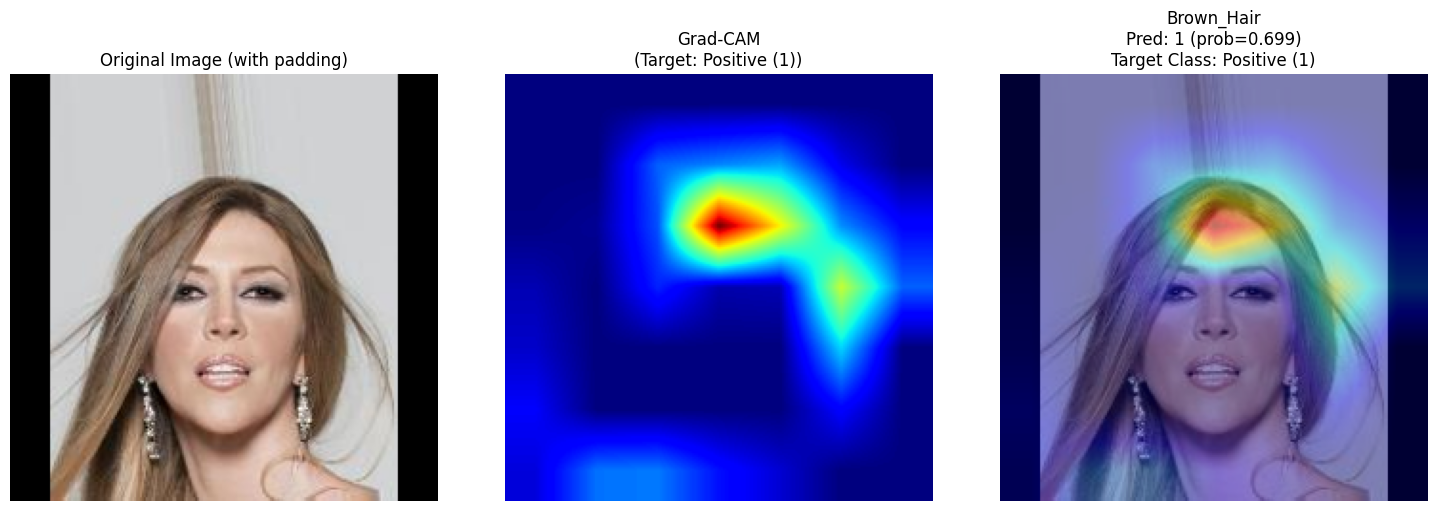


=== Grad-CAM for NEGATIVE class (attribute absent) ===


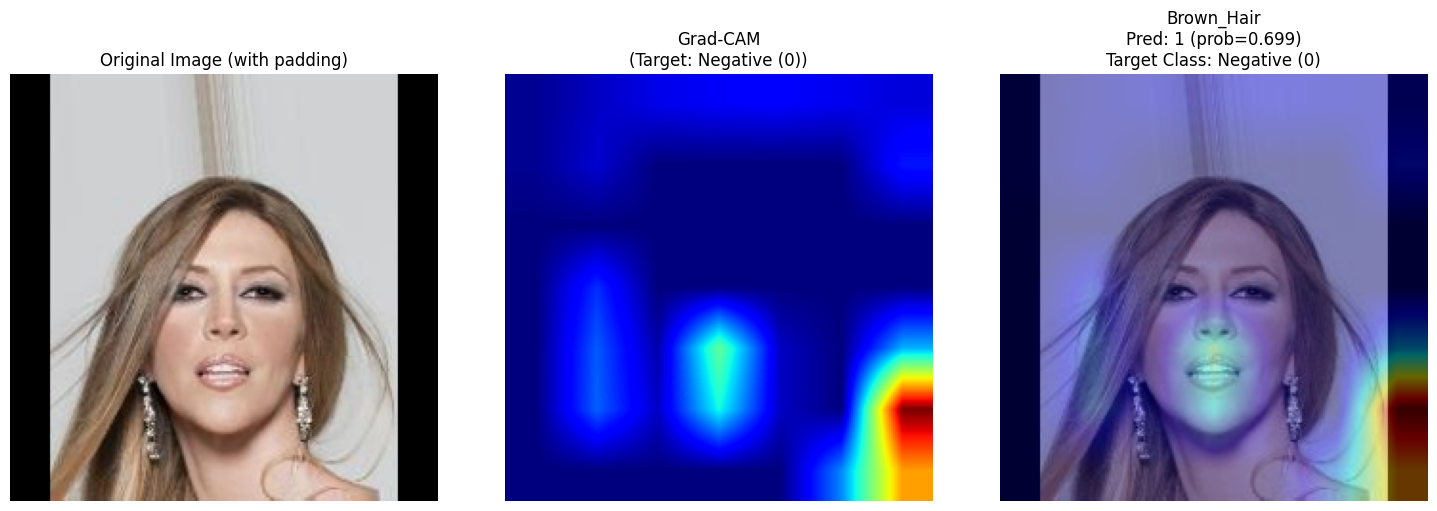

In [ ]:
# --- 6. GRAD-CAM VISUALIZATION ---
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[132])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Grad-CAM for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE prediction (attribute present)
print("\n=== Grad-CAM for POSITIVE class (attribute present) ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.layer4,
    target_class=1,
    alpha=0.4,
    image_size=IMAGE_SIZE,
    method='gradcam'
)

# Visualize for NEGATIVE prediction (attribute absent)
print("\n=== Grad-CAM for NEGATIVE class (attribute absent) ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.layer4,
    target_class=0,
    alpha=0.4,
    image_size=IMAGE_SIZE,
    method='gradcam'
)

Visualizing Grad-CAM++ for attribute: Brown_Hair

=== Grad-CAM++ for POSITIVE class ===


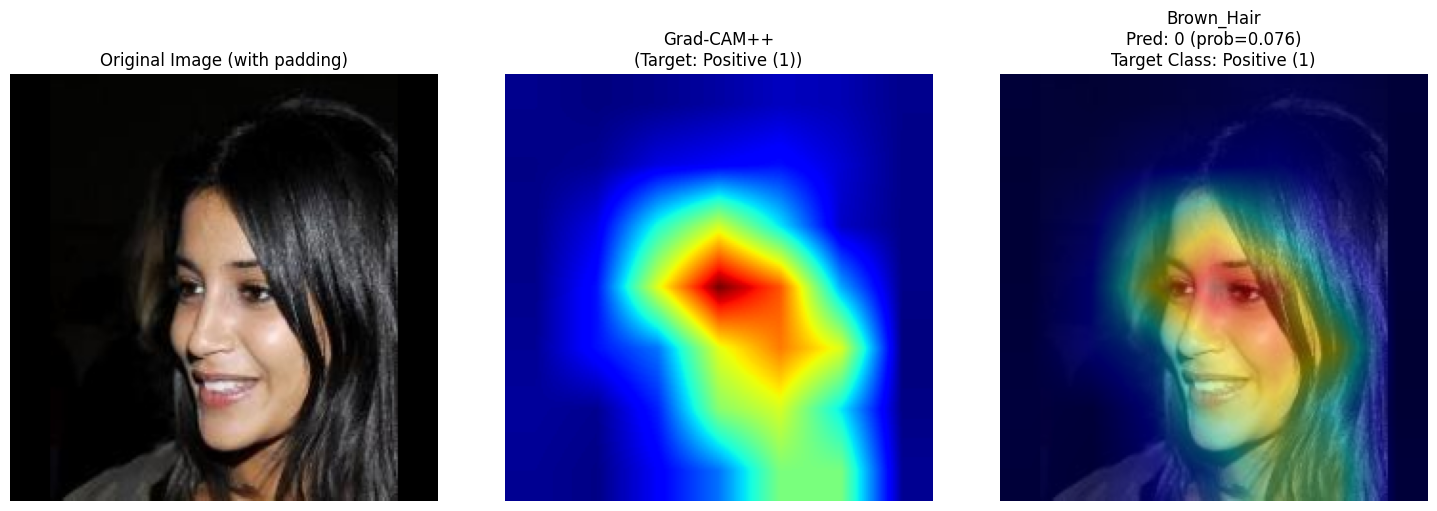


=== Grad-CAM++ for NEGATIVE class ===


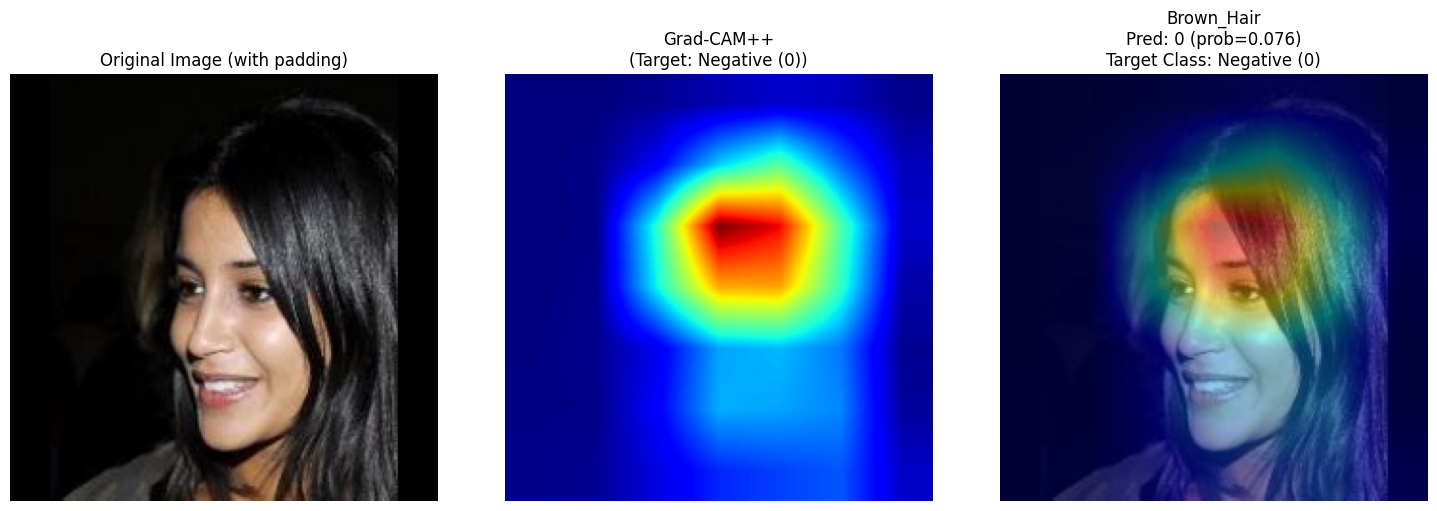

In [ ]:
# --- 7. GRAD-CAM++ VISUALIZATION ---
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[127])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Grad-CAM++ for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Grad-CAM++ for POSITIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.cbam4,
    target_class=1,
    alpha=0.4,
    image_size=IMAGE_SIZE,
    method='gradcam++'
)

# Visualize for NEGATIVE class
print("\n=== Grad-CAM++ for NEGATIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.cbam4,
    target_class=0,
    alpha=0.4,
    image_size=IMAGE_SIZE,
    method='gradcam++'
)

Visualizing Integrated Gradients for attribute: Brown_Hair

=== Integrated Gradients for POSITIVE class ===


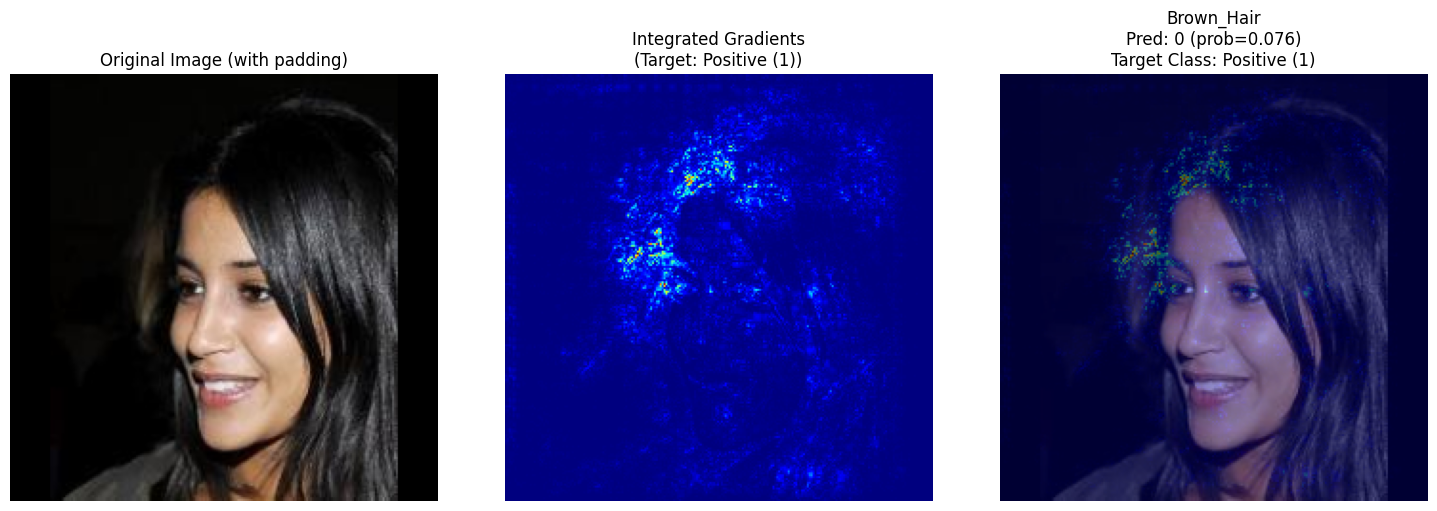


=== Integrated Gradients for NEGATIVE class ===


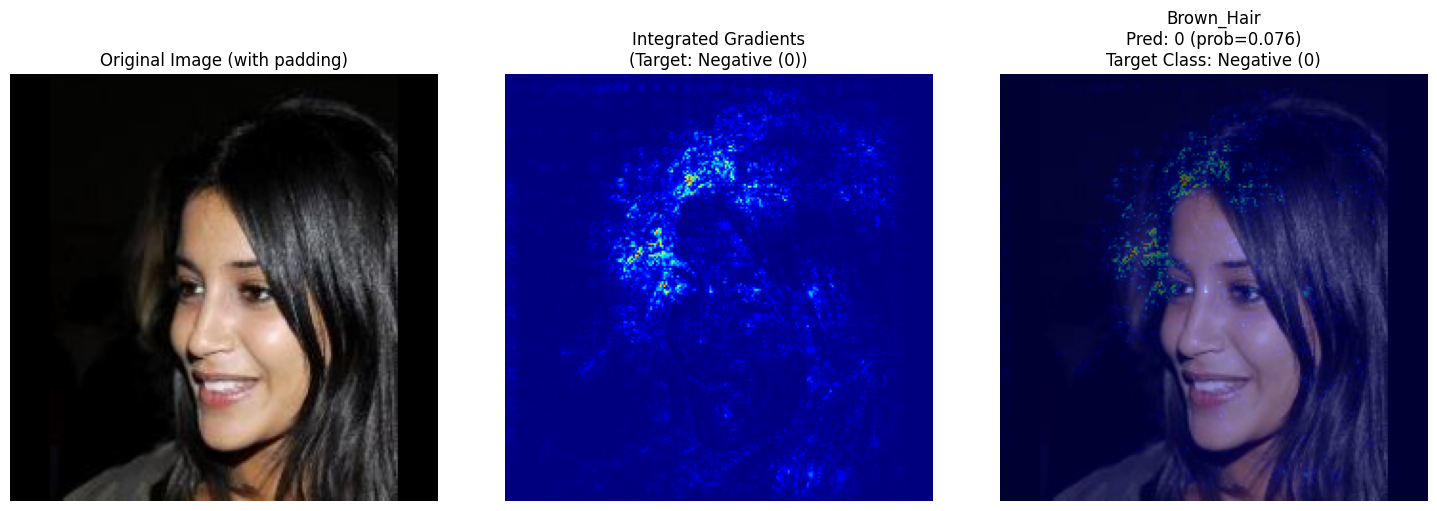

In [ ]:
# --- 8. INTEGRATED GRADIENTS ---
model.eval()

sample_img_path = os.path.join(IMAGE_PATH, val_df.index[127])
attr_idx = attribute_names.index("Brown_Hair")

print(f"Visualizing Integrated Gradients for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Integrated Gradients for POSITIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=1,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Visualize for NEGATIVE class
print("\n=== Integrated Gradients for NEGATIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=0,
    steps=50,
    alpha=0.4,
    image_size=IMAGE_SIZE
)

# Test No.2: Training and testing the newly refactored vq_vae

### HR-VQGAN Training Setup
Initialize and configure the HR-VQGAN (Hierarchical Residual VQ-VAE with Discriminator) for unsupervised training on CelebA.

In [1]:
import torch
from src.unsupervised_latentspace.config import cfg
from src.unsupervised_latentspace.trainer import train

# ============================================================================
# HVQ-GAN Training V3 - Step-based Unsupervised Training
# ============================================================================

print("="*70)
print("🔧 HVQ-GAN TRAINING V3")
print("="*70)

# Configuration
cfg.total_steps = 30000        # Total training steps
cfg.batch_size = 16             # Batch size
cfg.save_interval = 2500        # Save checkpoint every 2500 steps
cfg.sample_interval = 1000     # ✅ INCREASE: Sample every 1000 steps (less frequent)
cfg.log_interval = 1           # Log every 1 step
cfg.num_samples = 8
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"
cfg.data_path = "Dataset/celeba_70percent_721/train"
cfg.save_dir = "./outputs/checkpoints_production"
cfg.disc_start_step = 25000      # Start discriminator after 10000 steps warmup
cfg.use_amp = False             # ✅ DISABLE AMP initially (causing overflow)

print(f"\n📋 Configuration:")
print(f"   Device: {cfg.device}")
print(f"   Image Size: {cfg.image_size}x{cfg.image_size}")
print(f"   Batch Size: {cfg.batch_size}")
print(f"   Total Steps: {cfg.total_steps:,}")
print(f"   Log Interval: {cfg.log_interval} steps")
print(f"   Save Interval: {cfg.save_interval:,} steps")
print(f"   Sample Interval: {cfg.sample_interval:,} steps")
print(f"   Discriminator Start: Step {cfg.disc_start_step:,}")
print(f"   Learning Rate: {cfg.learning_rate}")
print(f"   Use AMP: {cfg.use_amp} (disabled for stability)")
print(f"   Loss Weights: {cfg.weights}")
print("="*70 + "\n")

# Verify data path
import os
if not os.path.exists(cfg.data_path):
    print(f"⚠️  WARNING: Data path not found: {cfg.data_path}")
    print(f"   Please update cfg.data_path to point to your CelebA dataset")
else:
    img_dir = os.path.join(cfg.data_path, "img_align_celeba")
    if os.path.exists(img_dir):
        num_images = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
        print(f"✅ Found {num_images} training images")
    else:
        print(f"⚠️  Image directory not found: {img_dir}")

print("\n🚀 Starting step-based training...\n")

try:
    train()
    print("\n" + "="*70)
    print("✅ HVQ-GAN TRAINING COMPLETED!")
    print("="*70)
    print(f"\n📁 Checkpoints saved to: {cfg.save_dir}")
    print(f"📁 Samples saved to: {os.path.join(cfg.save_dir, 'samples')}")
    print(f"📁 Logs saved to: {os.path.join(cfg.save_dir, 'logs')}")
except KeyboardInterrupt:
    print("\n⏹️  Training interrupted by user")
except Exception as e:
    print(f"\n❌ Training error: {e}")
    import traceback
    traceback.print_exc()

🔧 HVQ-GAN TRAINING V3 (Step-based)

📋 Configuration:
   Device: cuda
   Image Size: 128x128
   Batch Size: 16
   Total Steps: 30,000
   Log Interval: 1 steps
   Save Interval: 2,500 steps
   Sample Interval: 1,000 steps
   Discriminator Start: Step 25,000
   Learning Rate: 0.0003
   Use AMP: False (disabled for stability)
   Loss Weights: {'recon': 1.0, 'vq': 1.0, 'perceptual': 1.0, 'disc': 0.8}

✅ Found 99272 training images

🚀 Starting step-based training...

🔧 HVQ-GAN TRAINING V3 (Step-based, Unsupervised)
Device: cuda
Total Steps: 30,000
Batch Size: 16
Log Interval: 1 steps
Save Interval: 2,500 steps
Sample Interval: 1,000 steps
📁 Output Directory: ./outputs/checkpoints_production
   ├── checkpoints/              (model checkpoints)
   ├── samples/                  (progressive decoding visualizations)
   ├── metrics_and_visualisations/ (training metrics & analysis)
   └── logs/                     (training logs)

Loading VGG for Perceptual Loss...


/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ VGG loaded

Training images: 99272
Batches per cycle: 6205



Training:   8%|▊         | 2500/30000 [04:30<45:39, 10.04step/s, Tot=0.4043, Rec=0.0205, VQ=0.0243, Perc=0.3594, Ppl=158.72]  


📊 CREATING EVALUATION REPORT AT STEP 2,500
✅ Metrics comparison saved: metrics_comparison_step_2500.png
✅ Cascade hierarchy saved: cascade_hierarchy_step_2500.png

   Metrics history: metrics_history.csv

✅ Step 2,500 Checkpoint:
   Checkpoint: checkpoint_step_2500.pth
   Metrics: MSE=0.0205, PSNR=22.89 dB, SSIM=0.786
   Codebook: Top usage=0.4%, Mid usage=0.4%, Bottom usage=0.4%


...

Training: 100%|██████████| 30000/30000 [1:23:10<00:00,  6.16step/s, Tot=0.3880, Rec=0.0213, VQ=0.0294, Perc=0.3416, Ppl=210.45, DiscG=0.7961, DiscD=0.8607]   


📊 CREATING EVALUATION REPORT AT STEP 30,000
✅ Metrics comparison saved: metrics_comparison_step_30000.png


Training: 100%|██████████| 30000/30000 [1:25:29<00:00,  5.85step/s, Tot=0.3880, Rec=0.0213, VQ=0.0294, Perc=0.3416, Ppl=210.45, DiscG=0.7961, DiscD=0.8607]

✅ Cascade hierarchy saved: cascade_hierarchy_step_30000.png

   Metrics history: metrics_history.csv

✅ Step 30,000 Checkpoint:
   Checkpoint: checkpoint_step_30000.pth
   Metrics: MSE=0.0213, PSNR=22.73 dB, SSIM=0.846
   Codebook: Top usage=0.4%, Mid usage=0.4%, Bottom usage=0.4%

✅ HVQ-GAN TRAINING COMPLETED SUCCESSFULLY!

📁 Output Structure:
   ./outputs/checkpoints_production/
   ├── checkpoints/
   │   ├── checkpoint_step_5000.pth
   │   ├── checkpoint_step_10000.pth
   │   └── model_latest.pth
   ├── samples/
   │   ├── progressive_step_2500_comparison.png
   │   ├── progressive_step_5000_comparison.png
   │   └── progressive_step_10000_comparison.png
   ├── metrics_and_visualisations/
   │   ├── loss_curves_step_5000.png
   │   ├── metrics_comparison_step_5000.png
   │   ├── cascade_hierarchy_step_5000.png
   │   ├── codebook_usage_step_5000.png
   │   ├── codebook_analysis_step_5000.txt
   │   └── metrics_history.csv
   └── logs/
       └── training_log.txt

📊 Final step: 30,00


✅ HVQ-GAN TRAINING COMPLETED!

📁 Checkpoints saved to: ./outputs/checkpoints_production
📁 Samples saved to: ./outputs/checkpoints_production/samples
📁 Logs saved to: ./outputs/checkpoints_production/logs


# Test 3: Training Counterfactual Generator (ceGAN)
Initialize and train the comprehensive counterfactual generation model with logging, checkpointing, and visualization.

In [1]:
# Hyperparameter Initialization
from src.synthesis.config import Config

cfg = Config()
cfg.decoder_pretrain_epochs = 10
cfg.decoder_lr = 1e-3
cfg.decoder_checkpoint_dir = "outputs/synth_network/stylegan_decoder"
cfg.decoder_checkpoint_path = "outputs/synth_network/stylegan_decoder/latest.pth"
cfg.batch_size = 16
cfg.num_epochs = 20
cfg.accumulation_steps = 8
cfg.num_workers = 6
cfg.learning_rate = 1e-4
cfg.data_root = "Dataset/celeba_70percent_721/train"

# StyleGAN Decoder Pre-Training
from src.synthesis.dataset import get_loader
from src.synthesis.train_comprehensive import ComprehensiveTrainer

loader_train = get_loader(cfg, split='train', batch_size=cfg.batch_size, shuffle=True)
loader_val = get_loader(cfg, split='val', batch_size=cfg.batch_size, shuffle=False)

Loaded train split: 69490 images
Loaded val split: 9927 images


## Decoder Pre-training

In [ ]:
trainer = ComprehensiveTrainer(cfg, experiment_name="ceGAN_counterfactual")
trainer.recon_training(loader_train)

Loaded train split: 69490 images
Loaded val split: 9927 images
📁 Experiment directory: outputs/experiments/ceGAN_counterfactual_20251211_162329
⚠️ Decoder checkpoint not found at outputs/synth_network/stylegan_decoder/latest.pth; starting with random weights.
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
ℹ️ Decoder checkpoint not found at outputs/synth_network/stylegan_decoder/latest.pth; will train the decoder from scratch.
🎯 Starting StyleGAN decoder pre-training for 10 epoch(s)


[Decoder Pretrain] 0: 100%|██████████| 4343/4343 [13:12<00:00,  5.48it/s, L1=0.0551, LPIPS=0.135]


🖼️ Generating reconstruction preview...
🖼️ Saved decoder preview: outputs/synth_network/stylegan_decoder/previews/epoch_000.png
💾 Saved decoder checkpoints to outputs/synth_network/stylegan_decoder/decoder_pretrained.pth and outputs/synth_network/stylegan_decoder/latest.pth


...

🖼️ Generating reconstruction preview...
🖼️ Saved decoder preview: outputs/synth_network/stylegan_decoder/previews/epoch_007.png


[Decoder Pretrain] 8: 100%|██████████| 4343/4343 [12:43<00:00,  5.69it/s, L1=0.0432, LPIPS=0.103] 


🖼️ Generating reconstruction preview...
🖼️ Saved decoder preview: outputs/synth_network/stylegan_decoder/previews/epoch_008.png


[Decoder Pretrain] 9: 100%|██████████| 4343/4343 [13:18<00:00,  5.44it/s, L1=0.0504, LPIPS=0.105] 


🖼️ Generating reconstruction preview...
🖼️ Saved decoder preview: outputs/synth_network/stylegan_decoder/previews/epoch_009.png
✅ Decoder pre-training complete


## Decoder refinement training

In [2]:
# GAN refinement (decoder sharpening)
print("dataset at:", cfg.data_root)


from src.synthesis.train_sharpening import train_sharpening
train_sharpening(cfg.decoder_checkpoint_path, cfg=cfg)

dataset at: Dataset/celeba_70percent_721/train
🧭 Loaded StyleGAN decoder weights from outputs/synth_network/stylegan_decoder/latest.pth
🔄 Loading pre-trained decoder for sharpening: outputs/synth_network/stylegan_decoder/latest.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Loaded train split: 69490 images
Loaded val split: 9927 images
🚀 Starting adversarial sharpening phase...


Sharpening Epoch 0: 100%|██████████| 8686/8686 [41:46<00:00,  3.47it/s, D=1.62, G_Adv=0.118, L1=0.0509, LPIPS=0.124]    


💾 Saved EMA decoder weights to outputs/synth_network/stylegan_decoder_sharpened


...

Sharpening Epoch 16: 100%|██████████| 8686/8686 [21:11<00:00,  6.83it/s, D=0.552, G_Adv=0.871, L1=0.0518, LPIPS=0.141]   


💾 Saved EMA decoder weights to outputs/synth_network/stylegan_decoder_sharpened


Sharpening Epoch 18: 100%|██████████| 8686/8686 [21:09<00:00,  6.84it/s, D=0.521, G_Adv=0.866, L1=0.0525, LPIPS=0.14]    


💾 Saved EMA decoder weights to outputs/synth_network/stylegan_decoder_sharpened


Sharpening Epoch 19: 100%|██████████| 8686/8686 [21:13<00:00,  6.82it/s, D=0.0641, G_Adv=1.05, L1=0.0575, LPIPS=0.153]   


## Synthesis pipeline training

In [1]:
# Hyperparameter Initialization
from src.synthesis.config import Config

cfg = Config()
cfg.decoder_pretrain_epochs = 10
cfg.decoder_lr = 1e-3
cfg.decoder_checkpoint_dir = "outputs/synth_network/stylegan_decoder"
cfg.decoder_checkpoint_path = "outputs/synth_network/stylegan_decoder/latest.pth"
cfg.batch_size = 16
cfg.num_epochs = 20
cfg.accumulation_steps = 8
cfg.num_workers = 6
cfg.learning_rate = 1e-4
cfg.data_root = "Dataset/celeba_70percent_721/train"

# StyleGAN Decoder Pre-Training
from src.synthesis.dataset import get_loader
from src.synthesis.train_comprehensive import ComprehensiveTrainer

loader_train = get_loader(cfg, split='train', batch_size=cfg.batch_size, shuffle=True)
loader_val = get_loader(cfg, split='val', batch_size=cfg.batch_size, shuffle=False)

Loaded train split: 69490 images
Loaded val split: 9927 images


In [ ]:
# Comprehensive Counterfactual Training
from importlib import reload
from src.synthesis import train_comprehensive as train_comprehensive_module
train_comprehensive_module = reload(train_comprehensive_module)
from src.synthesis.train_comprehensive import ComprehensiveTrainer

cfg.sharpened_decoder_path = "outputs/synth_network/stylegan_decoder_sharpened/sharp_epoch_10.pth"

trainer = ComprehensiveTrainer(cfg, experiment_name="ceGAN_counterfactual")
trainer.train(
    num_epochs=cfg.num_epochs,
    loader_train=loader_train,
    loader_val=loader_val
)

📁 Experiment directory: outputs/synth_network/CF_generator/ceGAN_counterfactual_20251215
🔄 Loading Sharpened StyleGAN decoder from outputs/synth_network/stylegan_decoder_sharpened/sharp_epoch_10.pth...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [on]


/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/a/Ubuntu/lab.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
🧭 Loaded decoder weights from outputs/synth_network/stylegan_decoder/latest.pth
🎯 Active synthesis attributes (12): Bald, Bangs, Black_Hair, Blond_Hair, Brown_Hair, Bushy_Eyebrows, Eyeglasses, Male, Mouth_Slightly_Open, Mustache, Pale_Skin, Young
🚀 Starting Comprehensive Counterfactual Training...
📊 Logging to: outputs/synth_network/CF_generator/ceGAN_counterfactual_20251215/logs
💾 Checkpoints to: outputs/synth_network/CF_generator/ceGAN_counterfactual_20251215/checkpoints
🎨 Visualizations to: outputs/synth_network/CF_generator/ceGAN_counterfactual_20251215/visualizations


Epoch 0 / 20:  11%|█         | 487/4343 [14:53<1:59:05,  1.85s/it, loss=6.7328, cf=0.326, ret=0.106, adv=1.285, d=0.640] 